# Implementação de Zero-Watermarking para Rastreabilidade Segura em Laudos Odontológicos
Nicole Grazzioli Golfeto, 202410473

## 1. Problema e Justificativa
Imagens radiológicas são dados sensíveis rigorosamente protegidos pela LGPD. Inserir marcas d'água clássicas (alteração de pixels) em documentos médicos é inaceitável, pois qualquer modificação pode ocultar patologias ou gerar falsos positivos anatômicos. Por outro lado, radiografias anonimizadas correm o risco de perda de rastreabilidade ou vazamento sem identificação de autoria.

A técnica de **Zero-Watermarking (Marca d'Água Zero)** garante a autenticidade e a proveniência do exame sem alterar um único pixel do arquivo original, preservando a integridade diagnóstica do paciente.

## 2. Objetivos
### Objetivo Geral
Desenvolver um protótipo funcional de Zero-Watermarking estrutural em Python para assegurar a rastreabilidade forense de radiografias odontológicas, mantendo integridade total da imagem original.

### Objetivos Específicos
1. Extrair a "impressão digital visual" dos ossos maxilares utilizando a Decomposição em Valores Singulares (SVD).
2. Garantir a anonimização dos pacientes utilizando criptografia na origem, antes da geração da chave de verificação.
3. Validar a resiliência algorítmica do modelo submetendo-o a ataques geométricos degradantes.

## 3. Metodologia Proposta e Ambiente
A Prova de Conceito (PoC) será desenvolvida no Google Colab. As imagens de teste serão extraídas do repositório público **Dental Panoramic X-rays dataset do Kaggle**.

**Bibliotecas base:** `cv2` (OpenCV), `numpy`, `hashlib` e `json`.

### 📌 Plano de Implementação: Configuração do Ambiente
1. Importar as bibliotecas necessárias.
2. Configurar o caminho (path) para a pasta de imagens do dataset de radiografias panorâmicas (ex: arquivos `.jpg` ou `.png`).
3. Criar funções auxiliares para carregar imagens e exibi-las na tela usando o Matplotlib.

✅ Ambiente configurado com sucesso! Imagem carregada.


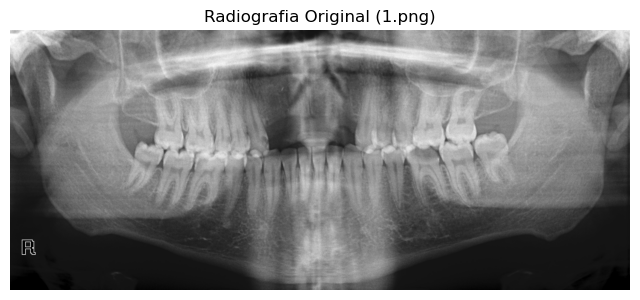

In [ ]:
# 1. Importação das bibliotecas necessárias
import cv2 # visão computacional - ler, redimensionar, borrar
import numpy as np # cálculos de matrizes
import hashlib # gerar códigos criptografados
import json # banco de dados simples
import os # arquivos e diretórios
import matplotlib.pyplot as plt # visualização de imagens e gráficos

# 2. Configuração do caminho do dataset
caminho_imagens = "./Images"

# 3. Função auxiliar para exibir imagens
def mostrar_imagem(titulo, imagem, cmap='gray'):
    plt.figure(figsize=(8, 6)) # janela 8x6 polegadas
    plt.imshow(imagem, cmap=cmap) # exibe a imagem com o mapa de cores especificado
    plt.title(titulo)
    plt.axis('off')
    plt.show()

# 4. Teste: Carregar e testar a primeira imagem
imagem_teste_path = os.path.join(caminho_imagens, "1.png")
imagem_teste = cv2.imread(imagem_teste_path, cv2.IMREAD_GRAYSCALE) # le a imagem em tons de cinza

if imagem_teste is not None:
    print("✅ Ambiente configurado com sucesso! Imagem carregada.")
    mostrar_imagem("Radiografia Original (1.png)", imagem_teste)
else:
    print("❌ Erro ao carregar a imagem. Verifique o caminho da pasta Images.")


--- 
### Parte 1: Geração da Proteção e Anonimização
#### 1.1 Desidentificação (Hash)
- Simulação dos metadados de entrada (ex: nome = "João da Silva" e data = "07/05/2026").
- A biblioteca `hashlib.sha256()` embaralha essas strings num identificador irreversível e anonimizado (Hash).
- O pareamento real é armazenado localmente em um arquivo `dicionario.json`.

**📌 Plano de Implementação:**
1. Criar variáveis fictícias: `nome_paciente` e `data_exame`.
2. Concatenar esses dados e aplicar `hashlib.sha256().hexdigest()` para obter o Hash de 256 bits.
3. Criar um dicionário Python associando o `Hash` ao valor original.
4. Salvar esse dicionário no arquivo `dicionario.json` (simulando um banco de dados seguro do hospital).

In [ ]:
# 1. Simulação dos metadados de entrada do paciente
nome_paciente = "João da Silva"
data_exame = "18/05/2026"
id_exame = "RX-PAN-1001"

# 2. Concatenação dos dados para formar uma string única
dados_brutos = f"{nome_paciente} | {data_exame} | {id_exame}"

# 3. Geração do Hash SHA-256 (Desidentificação irreversível)
hash_paciente = hashlib.sha256(dados_brutos.encode()).hexdigest()
    # .encode -- transforma a string em bytes 
    # sha256() -- algoritmo que gera o hash (código único irreversível)
    # hexdigest() -- retorna o hash em formato hexadecimal legível (para ser armazenado/exibido)

# 4. Criação do dicionário e pareamento com README de documentação embutido
dicionario_seguro = {
    "_readme": "DICIONÁRIO DE PACIENTES (Banco A): Mapeia o Hash SHA-256 (anônimo) aos dados reais do paciente. Dados sensíveis.",
    hash_paciente: dados_brutos
}

# 5. Salva as chaves no arquivo 'dicionario.json' (sobrescreve o arquivo)
with open('dicionario.json', 'w', encoding='utf-8') as arquivo_json:
    json.dump(dicionario_seguro, arquivo_json, ensure_ascii=False, indent=4)

# 6. Exibição dos resultados para visualização
print("=== PROCESSO DE ANONIMIZAÇÃO CONCLUÍDO ===")
print(f"Dados originais reveladores: '{dados_brutos}'")
print(f"Hash Seguro (Irreversível):  '{hash_paciente}'")
print("✅ Dicionário de pacientes gerado com documentação embutida!")


=== PROCESSO DE ANONIMIZAÇÃO CONCLUÍDO ===
Dados originais reveladores: 'João da Silva | 18/05/2026 | RX-PAN-1001'
Hash Seguro (Irreversível):  'eb4319d1b3d4f4f5ec3507a506013db2e14ddc0ad7366fce868098415317f1f4'
✅ Dicionário de pacientes gerado com documentação embutida!


#### 1.2 Extração da Identidade da Imagem
- O raio-X é lido em escala de cinza (`cv2.imread(..., cv2.IMREAD_GRAYSCALE)`) e redimensionado para 256x256 pixels (`cv2.resize()`).
- O algoritmo aplica o SVD do NumPy (`numpy.linalg.svd`) para extrair a matriz com a essência estrutural profunda dos dentes.
- Os valores são binarizados (0s e 1s) baseados na sua média.

**📌 Plano de Implementação:**
1. Carregar uma radiografia original e forçá-la para escala de cinza e tamanho $256 \times 256$.
2. Passar a imagem pela função `np.linalg.svd(imagem)`, que retorna três matrizes: $U$, $S$, $V^T$.
3. Usar a matriz $U$ (ou $V^T$) que contém as características espaciais primárias da anatomia.
4. Calcular a média dos valores da matriz $U$.
5. Criar a **Matriz Binarizada (M_Bin)**: Se um elemento for maior ou igual à média, recebe `1`, senão recebe `0`.

In [ ]:
# 1. Carregar a radiografia em escala de cinza e redimensionar para 256x256 (padronizar)
img_original = cv2.imread(caminho_img, cv2.IMREAD_GRAYSCALE)
img_redimensionada = cv2.resize(img_original, (256, 256))

# 2. Aplicação da Decomposição em Valores Singulares (SVD)
# SVD é resistente a alterações visuais (ex: ruído, compressão)
U, S, Vt = np.linalg.svd(img_redim, full_matrices=False)
    # O SVD decompõe a imagem em 3 matrizes: U, S e Vt
    # A matriz 'U' guarda as características estruturais (biometria visual) da imagem
k = 10
    # k é o número de componentes singulares a serem mantidos - guarda a essencia da imagem mas sem detalhes sensíveis
img_k = np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))
    # reconstrução aproximada da imagem usando apenas os k maiores valores singulares

# 3. Cálculo da média da matriz U
# Achar o ponto de equilíbrio (valor médio) para transformar os números quebrados em bits (0s e 1s)
media_img_k = np.mean(img_k)

# 4. Binarização da Matriz U
# np.where: se o valor for >= média, vira 1; senão, vira 0
matriz_binarizada = np.where(U >= media_U, 1, 0).astype(np.uint8)

# 5. Exibição dos resultados 
print("=== EXTRAÇÃO DA IDENTIDADE VISUAL CONCLUÍDA ===")
print(f"Tamanho da imagem original: {img_original.shape}")
print(f"Tamanho da matriz U (Essência estrutural): {U.shape}")
print(f"Média calculada para binarização: {media_U:.5f}")
print("\nMatriz Binarizada Final (Amostra dos primeiros 5x5 pixels):")
print(matriz_binarizada[:5, :5])


=== EXTRAÇÃO DA IDENTIDADE VISUAL CONCLUÍDA ===
Tamanho da imagem original: (1300, 3100)
Tamanho da matriz U (Essência estrutural): (256, 256)
Média calculada para binarização: -0.00016

Matriz Binarizada Final (Amostra dos primeiros 5x5 pixels):
[[0 0 1 0 1]
 [0 0 1 0 1]
 [0 0 1 0 1]
 [0 0 1 0 1]
 [0 0 1 0 1]]


#### 1.3 Identificador Único e Registro
- É aplicada uma porta lógica XOR (`numpy.bitwise_xor`) entre a matriz binarizada da imagem e os bits do Hash do paciente, resultando na "Chave de Verificação", salva no arquivo `chaves_seguras.txt`.
- A imagem radiológica original não sofre nenhuma manipulação nos seus pixels.

**📌 Plano de Implementação:**
1. Converter o Hash (texto hexadecimal) em uma sequência de bits (0s e 1s) e redimensioná-lo/repeti-lo para criar uma **Matriz Hash** do mesmo tamanho da imagem binarizada ($256 \times 256$).
2. Aplicar a operação XOR: `chave_mestra = np.bitwise_xor(matriz_binarizada, matriz_hash)`.
3. Salvar a matriz `chave_mestra` no arquivo `chaves_seguras.txt`.
4. A imagem original segue intacta para o médico

In [ ]:
# 1. Conversão do Hash para uma Matriz de Bits (0s e 1s)
# int() e bin() --> converte o texto hexadecimal (hash_paciente) para binário
# [2:] --> ignora o '0b' que o Python coloca na frente dos binários
# zfill(256) --> garante que a linha tenha 256 bits (completa com zeros à esquerda se necessário)
hash_bits_string = bin(int(hash_paciente, 16))[2:].zfill(256)

# Transforma a string de 256 caracteres numa lista de números (array Numpy)
hash_array = np.array([int(b) for b in hash_bits_string], dtype=np.uint8)

# 2. Criação da "Matriz Hash"
# Como a imagem é 256x256, precisa de uma matriz de hash do mesmo tamanho
# np.tilem --> pega a linha de 256 números do hash e "imprime" 256 vezes para baixo
matriz_hash = np.tile(hash_array, (256, 1))

# 3. Marca D'água: Porta Lógica XOR
# O bitwise_xor compara a 'matriz_binarizada' (osso) com a 'matriz_hash' (dados do paciente) pixel a pixel
# se ambos forem iguais (0,0 ou 1,1) o resultado é 0; se forem diferentes (0,1 ou 1,0) o resultado é 1
# o resultado é a "chave mestra" que combina a biometria visual com os dados do paciente de forma segura e auditável, sem mexer na imagem original
chave_mestra = np.bitwise_xor(matriz_binarizada, matriz_hash)

# 4. Salvamento da Chave (Sobrescreve o arquivo) - salva a matriz em um arquivo de texto
# parâmetro 'header' coloca uma explicação no topo do txt sem prejudicar a leitura posterior do Numpy (as linhas começam com '#')
np.savetxt(
    "chaves_seguras.txt", 
    chave_mestra, 
    fmt='%d',
    header="CHAVE MESTRA ZERO-WATERMARK (Imagem 1.png)\nEsta matriz 256x256 representa a fusao XOR da biometria ossea extraida com o Hash do paciente Joao da Silva.\nServe para auditar a proveniencia sem alterar pixels do raio-X. Para ler novamente no numpy use np.loadtxt('chaves_seguras.txt')"
)

print("=== REGISTRO ÚNICO (ZERO-WATERMARK) CONCLUÍDO ===")
print("✅ Operação XOR executada com sucesso")
print("✅ 'chaves_seguras.txt' gerado com cabeçalho explicativo!")


=== REGISTRO ÚNICO (ZERO-WATERMARK) CONCLUÍDO ===
✅ Operação XOR executada com sucesso
✅ 'chaves_seguras.txt' gerado com cabeçalho explicativo!


#### 1.4 Automação e Processamento em escala
No mundo real, o sistema processa centenas de imagens. Vamos simular isso pegando **todas** as imagens da nossa pasta, extraindo as identidades e salvando as chaves em um único `banco_de_chaves.json`.

**📌 Plano de Implementação:**
1. Varrer a pasta `/Images` buscando todos os arquivos `.png`.
2. Para cada imagem, simular o `Hash` do paciente e salvar no `dicionario.json`.
3. Fazer o SVD, binarizar e rodar o XOR para criar a `chave_mestra`.
4. Aplanar os 65.536 bits da chave em uma única linha de texto (String).
5. Salvar no `banco_de_chaves.json` (ID da imagem -> Chave em texto).

In [ ]:
# Parte 1.4: Processamento em Lote do Dataset
import glob # varre o pc e retorna uma lista com todos os arquivos que batem com um padrão especificado

dicionario_completo = {}
banco_de_chaves = {}

# 1. Inserir cabeçalho informativo explicativo (README) embutido nos bancos de dados para que a documentação nunca se apague
dicionario_completo["_readme"] = "DICIONARIO DE PACIENTES (Banco A): Mapeia o Hash SHA-256 (anonimo) aos dados reais do paciente. Dados sensíveis."
banco_de_chaves["_readme"] = "BANCO DE CHAVES DE VERIFICACAO (Banco B): Mapeia o ID da radiografia a sua chave mestra zero-watermark de bits aplanada. Nao contem dados pessoais dos pacientes, apenas o Hash do paciente para ligacao forense no processo de auditoria."

# 2. Varrer todas as imagens da pasta
lista_imagens = glob.glob(os.path.join(caminho_imagens, "*.png"))
print(f"Iniciando processamento em lote de {len(lista_imagens)} imagens...")

for caminho_img in lista_imagens:
    nome_arquivo = os.path.basename(caminho_img)
    id_exame = nome_arquivo.split('.')[0] # Ex: '1', '2', '3'
    
    # 3. Criar metadados fictícios para cada paciente
    nome_paciente = f"Paciente_Original_{id_exame}"
    dados_brutos = f"{nome_paciente} | Data_Simulada | RX-PAN-{id_exame}"
    hash_paciente = hashlib.sha256(dados_brutos.encode()).hexdigest()
    dicionario_completo[hash_paciente] = dados_brutos
    
    # 4. Matemática: SVD e Binarização
    img = cv2.imread(caminho_img, cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    
    img_redim = cv2.resize(img, (256, 256))
    # Usando os 10 maiores valores singulares 
    U, S, Vt = np.linalg.svd(img_redim, full_matrices=False)
    k = 10
    img_k = np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))
    media_img_k = np.mean(img_k)
    matriz_bin = np.where(img_k >= media_img_k, 1, 0).astype(np.uint8)
    
    # 5. Hash para bits e criação da Matriz Hash 256x256
    hash_bits = bin(int(hash_paciente, 16))[2:].zfill(256)
    hash_array = np.array([int(b) for b in hash_bits], dtype=np.uint8)
    matriz_hash = np.tile(hash_array, (256, 1))
    
    # 6. XOR para criar a Chave Mestra
    chave_mestra = np.bitwise_xor(matriz_bin, matriz_hash)
    
    # 7. Aplanar a matriz 2D para uma String 1D 
    # Salvar um texto ocupa muito menos espaço em um banco de dados do que uma matriz
    # flatten() --> transforma a matriz 256x256 para uma única linha de 65.536 bits
    # join --> converte para string '100101...'
    chave_flat_string = ''.join(chave_mestra.flatten().astype(str))
    
    banco_de_chaves[id_exame] = {
        "hash_paciente": hash_paciente,
        "chave_mestra_bits": chave_flat_string
    }

# 8. Salvar os arquivos consolidados (sobrescrevendo de forma atualizada)
with open('dicionario.json', 'w', encoding='utf-8') as f:
    json.dump(dicionario_completo, f, ensure_ascii=False, indent=4)

with open('banco_de_chaves.json', 'w', encoding='utf-8') as f:
    json.dump(banco_de_chaves, f, ensure_ascii=False, indent=4)

print("✅ Processamento em Lote Concluído!")
print("✅ 'dicionario.json' populado com todos os pacientes e com README embutido.")
print("✅ 'banco_de_chaves.json' gerado com todas as chaves compactadas e README de explicação embutido!")


Iniciando processamento em lote de 30 imagens...
✅ Processamento em Lote Concluído!
✅ 'dicionario.json' populado com todos os pacientes e com README embutido.
✅ 'banco_de_chaves.json' gerado com todas as chaves compactadas e README de explicação embutido!


--- 
### Parte 2: Validação e Engenharia Reversa (Simulação de Vazamento)
#### 2.1 Degradação
- A imagem intacta sofre degradação proposital para simular um vazamento. 
- O arquivo é salvo com forte compressão com perdas (JPEG) ou embaçado via `cv2.GaussianBlur` (Filtro Gaussiano), resultando no arquivo `dente_vazado.jpg`.

**📌 Plano de Implementação:**
1. Pegar a imagem original.
2. Aplicar um borramento severo `cv2.GaussianBlur(img, (15, 15), 0)`.
3. Salvar como um JPEG com baixíssima qualidade (ex: 20% de qualidade) usando `cv2.imwrite('dente_vazado.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 20])`.

[Ataque Forense] Imagem degradada salva em: ./imagens-vazadas\dente_vazado.jpg


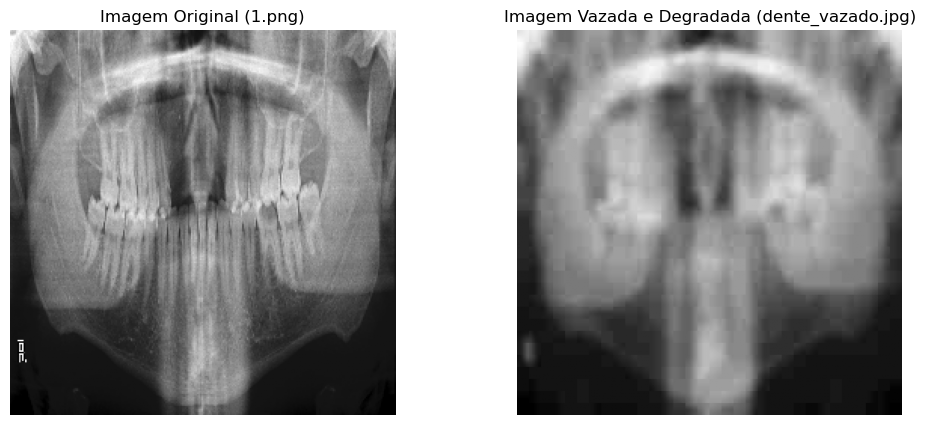

In [18]:
# Passo 1: Carregar a imagem original
img_original_path = "./Images/1.png"
img_original = cv2.imread(img_original_path, cv2.IMREAD_GRAYSCALE)
img_original = cv2.resize(img_original, (256, 256)) # Padronizando tamanho

# Passo 2: Aplicar degradação severa (Gaussian Blur)
img_borrada = cv2.GaussianBlur(img_original, (15, 15), 0)

# Passo 3: Criar pasta e salvar com baixa qualidade JPEG (simulando vazamento)
import os
pasta_vazadas = "./imagens-vazadas"
os.makedirs(pasta_vazadas, exist_ok=True)
vazamento_path = os.path.join(pasta_vazadas, "dente_vazado.jpg")
cv2.imwrite(vazamento_path, img_borrada, [int(cv2.IMWRITE_JPEG_QUALITY), 20])
print(f"[Ataque Forense] Imagem degradada salva em: {vazamento_path}")

# Passo 4: Exibir as imagens para comparação
img_vazada = cv2.imread(vazamento_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Imagem Original (1.png)")
plt.imshow(img_original, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Imagem Vazada e Degradada (dente_vazado.jpg)")
plt.imshow(img_vazada, cmap="gray")
plt.axis("off")

plt.show()


#### 2.2 Engenharia Reversa
- O sistema abre a foto `dente_vazado.jpg`, redimensiona para 256x256 e executa o SVD novamente para re-extrair a matriz do osso binarizada.
- O script lê o arquivo `banco_de_chaves.json`, recupera a chave original e roda um XOR reverso com a nova matriz suja. Se a matemática resistir, o Hash criptografado é revelado.
- O script varre o `dicionario.json` e imprime o alerta na tela: "Imagem vazada identificada: paciente João da Silva".

**📌 Plano de Implementação:**
1. O sistema "encontra" a imagem degradada `dente_vazado.jpg`.
2. Converte para cinza, ajusta para 256x256 e aplica o SVD e a Binarização da mesma forma que antes, obtendo a **Matriz Binarizada Suja**.
3. Percorre o `banco_de_chaves.json` buscando a chave que mais se assemelha.
4. Para cada chave do banco, recria a matriz original 256x256 e executa o XOR reverso: `hash_extraido = np.bitwise_xor(matriz_binarizada_suja, chave_mestra)`.
5. Calculamos a taxa de similaridade (Bit Error Rate). Se for alta (ex: > 90%), reconstruímos o Hash.
6. Consultamos `dicionario.json` e imprimimos o infrator.

In [19]:
# 1. Carregar a imagem suja/vazada e os bancos de dados
import os
caminho_vazada = "./imagens-vazadas/dente_vazado.jpg"
img_suja = cv2.imread(caminho_vazada, cv2.IMREAD_GRAYSCALE)

# Redimensionar para o padrão 256x256
img_suja = cv2.resize(img_suja, (256, 256))

# Carregar os arquivos de segurança (Dicionário e Banco de Chaves)
with open('dicionario.json', 'r', encoding='utf-8') as f:
    dicionario_completo = json.load(f)
with open('banco_de_chaves.json', 'r', encoding='utf-8') as f:
    banco_de_chaves = json.load(f)

# 2. Refazer SVD e binarização (Extração do esqueleto da imagem degradada)
U_sujo, S_sujo, Vt_sujo = np.linalg.svd(img_suja, full_matrices=False)
k = 10
img_suja_k = np.dot(U_sujo[:, :k], np.dot(np.diag(S_sujo[:k]), Vt_sujo[:k, :]))
media_U_sujo = np.mean(img_suja_k)
matriz_bin_suja = np.where(img_suja_k >= media_U_sujo, 1, 0).astype(np.uint8)

# Variáveis para encontrar a chave mais parecida
melhor_ber = float('inf') # Bit Error Rate (quanto menor, mais parecida)
hash_encontrado = None
id_encontrado = None

print("🕵️ Iniciando Varredura Forense no Banco de Chaves...\n")

# 3. Varredura: Comparar a imagem suja com todas as chaves do banco de dados
for id_exame, dados in banco_de_chaves.items():
    if id_exame == "_readme": continue # Pular os metadados explicativos
    
    # Pegar a string de bits aplanada e converter de volta para matriz numpy 256x256
    bits_string = dados["chave_mestra_bits"]
    chave_mestra_recuperada = np.array([int(b) for b in bits_string], dtype=np.uint8).reshape((256, 256))
    
    # 4. XOR Reverso: matriz binarizada suja XOR chave mestra do banco = hash aproximado
    matriz_hash_aproximada = np.bitwise_xor(matriz_bin_suja, chave_mestra_recuperada)
    
    # Para saber a similaridade real, transformamos em bits o Hash original salvo no banco para aquele ID e comparamos
    hash_original_bits = bin(int(dados["hash_paciente"], 16))[2:].zfill(256)
    hash_original_array = np.array([int(b) for b in hash_original_bits], dtype=np.uint8)
    matriz_hash_original = np.tile(hash_original_array, (256, 1))
    
    # Calcular o Bit Error Rate (BER) - Taxa de erro de bits entre o que foi recuperado e o original
    # Calcula quantos bits deram diferente e divide pelo total de bits
    erros = np.sum(matriz_hash_aproximada != matriz_hash_original)
    taxa_erro = erros / (256 * 256)
    
    if taxa_erro < melhor_ber:
        melhor_ber = taxa_erro
        hash_encontrado = dados["hash_paciente"]
        id_encontrado = id_exame

# 5. Avaliação da Taxa de Erro e Revelação do Paciente
similaridade = (1 - melhor_ber) * 100
print(f"📊 Fim da Varredura. Maior similaridade encontrada: {similaridade:.2f}% (BER: {melhor_ber:.4f})")

if similaridade >= 90.0:
    print("✅ Autoria confirmada matematicamente! (Similaridade > 90%)\n")
    
    # 6. Consultar Dicionário (Quebra do sigilo forense)
    if hash_encontrado in dicionario_completo:
        dados_reais = dicionario_completo[hash_encontrado]
        print("🚨 [ALERTA DE VAZAMENTO] 🚨")
        print(f"A imagem degradada 'dente_vazado.jpg' pertence ao paciente:")
        print(f"➔ {dados_reais}")
    else:
        print("Hash encontrado, mas paciente não está no dicionário.")
else:
    print("❌ Não foi possível encontrar um match confiável no banco de dados.")


🕵️ Iniciando Varredura Forense no Banco de Chaves...

📊 Fim da Varredura. Maior similaridade encontrada: 96.30% (BER: 0.0370)
✅ Autoria confirmada matematicamente! (Similaridade > 90%)

🚨 [ALERTA DE VAZAMENTO] 🚨
A imagem degradada 'dente_vazado.jpg' pertence ao paciente:
➔ Paciente_Original_1 | Data_Simulada | RX-PAN-1


## 4. Resultados Esperados
Espera-se provar a superioridade e adequação do Zero-Watermarking aliado à técnica SVD para a área da saúde. A "biometria óssea visual" da radiografia deve ser capaz de sobreviver a ataques agressivos de filtro passa-baixa e perdas de frequência (JPEG). O sistema deve localizar a autoria do vazamento com velocidade, garantindo a rastreabilidade total de dados não estruturados sem causar danos à integridade do laudo clínico, cumprindo com as prerrogativas de segurança da LGPD.